# 05 · KL modes and turbulence statistics

**Who this is for:** you control turbulence and want to understand, and use, what KL modes encode. That includes the eigenvalues as a statistical prior, the effect of r₀ and L₀, Kolmogorov turbulence, and simulating turbulence on the actuators.

## What a KL basis is

Atmospheric phase is a random field. Under Von Kármán statistics, the covariance between the phase at two points depends only on their separation r:

$$C(r) = \sigma^2 \, \frac{2^{1/6}}{\Gamma(5/6)} \left(\frac{2\pi r}{L_0}\right)^{5/6} K_{5/6}\!\left(\frac{2\pi r}{L_0}\right), \qquad \sigma^2 \approx 0.0863 \left(\frac{L_0}{r_0}\right)^{5/3}\ \text{rad}^2 .$$

Sampled at the actuators, this gives an `(N, N)` covariance matrix `C`. Its eigendecomposition `C = U Λ Uᵀ` defines the KL basis:

- the columns of `U` are the **modes** (orthonormal);
- `Λ` holds the **eigenvalues**, the variance of each mode's coefficient (rad² at the wavelength of r₀).

A turbulent phase on the actuators is then `φ = U a`, with **independent** coefficients `a_k` of variance `λ_k`. No other orthonormal basis puts more variance into its first k modes.

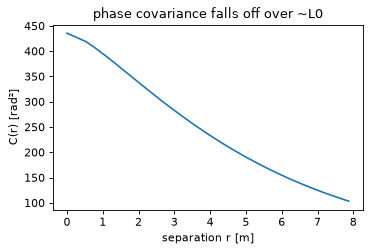

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import aobasis

plt.rcParams["figure.dpi"] = 80
D = 8.0
positions = aobasis.make_circular_actuator_grid(telescope_diameter=D, grid_size=16)
kl = aobasis.KLBasisGenerator(positions, fried_parameter=0.15, outer_scale=25.0)
cov = kl._von_karman_covariance_cpu()

r = np.linalg.norm(positions - positions[0], axis=1)
order = np.argsort(r)
plt.figure(figsize=(5, 3))
plt.plot(r[order], cov[0, order])
plt.xlabel("separation r [m]")
plt.ylabel("C(r) [rad²]")
plt.title("phase covariance falls off over ~L0")
plt.show()

## The eigenvalue spectrum, and what r₀, L₀ and λ do

- **r₀** (`fried_parameter`) only scales the covariance by r₀^(−5/3). The modes don't change, and the eigenvalues scale.
- **L₀** (`outer_scale`) changes the large-scale statistics. It matters most for the lowest modes, tip/tilt above all. `outer_scale=np.inf` gives Kolmogorov turbulence.
- **wavelength**: phase variance in rad² scales as (λ₀/λ)². By default eigenvalues are at `r0_wavelength` (500 nm); pass `wavelength=` to report them at your science or sensing wavelength.

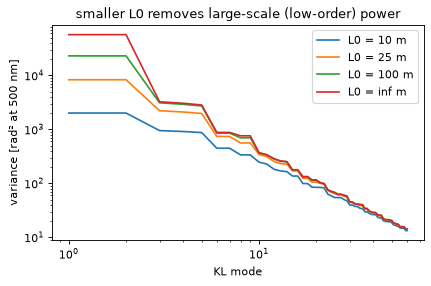

KL1 (tip) adds 48.4 rad² of aperture-averaged phase variance at 500 nm, 4.45 rad² at 1.65 µm


In [2]:
plt.figure(figsize=(6, 3.5))
for L0 in (10.0, 25.0, 100.0, np.inf):
    gen = aobasis.KLBasisGenerator(positions, fried_parameter=0.15, outer_scale=L0)
    gen.generate(60, ignore_piston=True)
    plt.loglog(np.arange(1, 61), gen.eigenvalues, label=f"L0 = {L0:g} m")
plt.xlabel("KL mode")
plt.ylabel("variance [rad² at 500 nm]")
plt.legend()
plt.title("smaller L0 removes large-scale (low-order) power")
plt.show()

h_band = aobasis.KLBasisGenerator(positions, fried_parameter=0.15, outer_scale=25.0, wavelength=1.65e-6)
h_band.generate(5, ignore_piston=True)
kl.generate(5, ignore_piston=True)
n = len(positions)
print(f"KL1 (tip) adds {kl.eigenvalues[0] / n:.1f} rad² of aperture-averaged phase variance at 500 nm, "
      f"{h_band.eigenvalues[0] / n:.2f} rad² at 1.65 µm")

**Units of the eigenvalues.** KL modes have unit L2 norm (‖m‖ = 1), so a mode's RMS over the N actuators is 1/√N. Its eigenvalue λ is the variance of its *coefficient*, and the phase variance it adds, averaged over the aperture, is λ/N. If you'd rather have coefficients in RMS phase, generate with `normalize="rms"`: the eigenvalues are rescaled so they stay the coefficient variances, and λ itself is then the aperture-averaged variance.

In [3]:
rms = aobasis.KLBasisGenerator(positions, fried_parameter=0.15, outer_scale=25.0)
rms.generate(5, ignore_piston=True, normalize="rms")
print("with normalize='rms', KL1 eigenvalue:", rms.eigenvalues[0].round(1), "rad²")

with normalize='rms', KL1 eigenvalue: 48.4 rad²


## Kolmogorov turbulence

With an infinite outer scale, the phase variance, and so the piston variance, is infinite. `KLBasisGenerator` then needs `ignore_piston=True`, and diagonalizes −½ P D P built from the structure function D(r) = 6.88 (r/r₀)^(5/3).

A check against theory: averaged over the aperture, the piston-removed variance is Noll's Δ₁ = 1.0299 (D/r₀)^(5/3), and with tip/tilt also removed it's Δ₃ = 0.134 (D/r₀)^(5/3). The sum of all KL eigenvalues divided by N is exactly that aperture average:

In [4]:
dense = aobasis.make_circular_actuator_grid(D, 40)
for remove, noll in ((None, 1.0299), ("tiptilt", 0.134)):
    gen = aobasis.KLBasisGenerator(dense, fried_parameter=0.15, outer_scale=np.inf)
    gen.generate(len(dense) - (3 if remove else 1), ignore_piston=True, remove=remove)
    measured = gen.eigenvalues.sum() / len(dense) / (D / 0.15) ** (5 / 3)
    print(f"removed piston{' + tip/tilt' if remove else ''}: {measured:.4f} (D/r0)^5/3   Noll: {noll}")

removed piston: 1.0242 (D/r0)^5/3   Noll: 1.0299


removed piston + tip/tilt: 0.1336 (D/r0)^5/3   Noll: 0.134


The small shortfall comes from sampling the pupil with 40 points across.

## Simulating turbulence on the actuators

The eigenvalues are all you need to draw random phase screens with exactly the right statistics, at the actuators: `φ = M a`, with `a_k ~ N(0, λ_k)`.

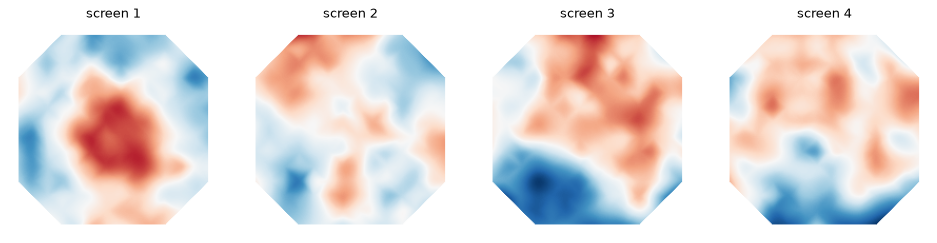

In [5]:
gen = aobasis.KLBasisGenerator(positions, fried_parameter=0.15, outer_scale=25.0)
m2c = gen.generate(len(positions) - 1, ignore_piston=True)
rng = np.random.default_rng(0)
coefficients = rng.standard_normal((m2c.shape[1], 4)) * np.sqrt(gen.eigenvalues)[:, None]
screens = m2c @ coefficients
aobasis.plot_basis_modes(screens, positions, count=4, title_prefix="screen", interpolate=True, cmap="RdBu_r")

Drawing many screens and comparing their sample covariance with the model checks the statistics:

In [6]:
many = m2c @ (rng.standard_normal((m2c.shape[1], 20000)) * np.sqrt(gen.eigenvalues)[:, None])
p = np.eye(len(positions)) - 1.0 / len(positions)
model = p @ cov @ p  # the piston-removed covariance
print("relative error of the sample covariance:", (np.linalg.norm(np.cov(many) - model) / np.linalg.norm(model)).round(3))

relative error of the sample covariance: 0.02


Use the eigenvalues the same way as a prior: a MAP (minimum-variance) reconstructor regularizes mode k by the noise variance over λ_k.

## Why KL: variance captured per mode

For an orthonormal basis M, the turbulence variance it captures is trace(Mᵀ C M). Comparing KL with orthonormalized Zernike and Fourier bases:

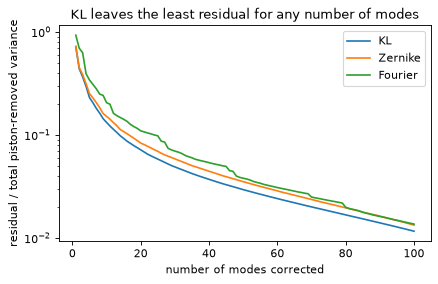

In [7]:
cp = p @ cov @ p
n_list = np.arange(1, 101)
curves = {
    "KL": gen.generate(100, ignore_piston=True),
    "Zernike": aobasis.ZernikeBasisGenerator(positions).generate(100, ignore_piston=True, orthonormalize=True),
    "Fourier": aobasis.FourierBasisGenerator(positions, D).generate(100, ignore_piston=True, orthonormalize=True),
}
total = np.trace(cp)
plt.figure(figsize=(6, 3.5))
for name, m in curves.items():
    captured = np.cumsum(np.einsum("ik,ij,jk->k", m, cp, m))
    plt.semilogy(n_list, 1 - captured / total, label=name)
plt.xlabel("number of modes corrected")
plt.ylabel("residual / total piston-removed variance")
plt.legend()
plt.title("KL leaves the least residual for any number of modes")
plt.show()

KL wins at every mode count, by construction. Zernike is close for low orders; Fourier needs more modes because its low frequencies aren't adapted to the circular pupil.

This is "sampled at the actuators" KL. If you have DM influence functions, `DMKLBasisGenerator` builds KL modes of the *DM surface* instead; see [06](06_influence_functions.ipynb).

## Reproducibility and the GPU

Eigenvectors are only defined up to sign, and up to rotation inside groups of equal eigenvalues, which symmetric pupils have many of. aobasis fixes both with a convention. Tip comes along +x and tilt along +y, astigmatism pairs follow cos 2θ then sin 2θ, and every machine produces the same modes. So an interaction matrix measured on one computer matches modes generated on another.

In [8]:
x, y = positions.T
m = gen.generate(2, ignore_piston=True)
print("KL1 vs x:", np.corrcoef(m[:, 0], x)[0, 1].round(3), "   KL2 vs y:", np.corrcoef(m[:, 1], y)[0, 1].round(3))

KL1 vs x: 0.989    KL2 vs y: 0.989


For large DMs, `use_gpu=True` builds and diagonalizes the covariance with CuPy (`pip install cupy-cuda12x`). It falls back to the CPU with a warning when CuPy isn't installed, and gives the same modes to ~1e-8. On the CPU, asking for only a few modes uses a partial eigensolver, so `generate(100)` on 3000 actuators takes about 2 s.

In [9]:
try:
    gpu = aobasis.KLBasisGenerator(positions, fried_parameter=0.15, outer_scale=25.0, use_gpu=True)
    same = np.allclose(gpu.generate(50, ignore_piston=True), gen.generate(50, ignore_piston=True), atol=1e-8)
    print("GPU used:", gpu.use_gpu, " same modes as CPU:", same)
except Exception as err:  # no CUDA device
    print("GPU not available:", err)

GPU used: True  same modes as CPU: True
